# Análisis del Gasto Público Nacional — 2024/2026

---

## Introducción

Este informe analiza la ejecución del gasto público nacional desde tres perspectivas:

1. **Composición por finalidad** — en qué grandes categorías gasta el Estado nacional (2025 y 2026)
2. **Gasto ejecutado en La Rioja** — cuánto del presupuesto nacional se destina a la provincia (2024)
3. **Comparación regional NOA** — posición de La Rioja respecto a las demás provincias del noroeste argentino

Los datos provienen del portal de datos abiertos del Ministerio de Economía de la Nación 
(presupuesto.gob.ar) y fueron procesados con Python.

In [ ]:
import pandas as pd
import os

# Ver qué archivos tenemos
carpeta = '../datos/raw'
for archivo in os.listdir(carpeta):
    print(archivo)

In [4]:
# Cargar los dos archivos
df_finalidad = pd.read_csv('../datos/raw/d-finalidad-funcion-2026.csv')
df_pib = pd.read_csv('../datos/raw/serie_pib_anual.csv')

# Ver las primeras filas de cada uno
print("=== GASTOS POR FINALIDAD ===")
print(df_finalidad.head())
print("\nColumnas:", df_finalidad.columns.tolist())

=== GASTOS POR FINALIDAD ===
   ejercicio_presupuestario  finalidad_id                finalidad_desc  \
0                      2026             1  ADMINISTRACION GUBERNAMENTAL   
1                      2026             1  ADMINISTRACION GUBERNAMENTAL   
2                      2026             1  ADMINISTRACION GUBERNAMENTAL   
3                      2026             1  ADMINISTRACION GUBERNAMENTAL   
4                      2026             1  ADMINISTRACION GUBERNAMENTAL   

   funcion_id                  funcion_desc  \
0           1                   Legislativa   
1           2                      Judicial   
2           3  Dirección Superior Ejecutiva   
3           4         Relaciones Exteriores   
4           5         Relaciones Interiores   

                          ultima_actualizacion_fecha  
0  Última actualización del ejercicio 2026: 06 Ma...  
1  Última actualización del ejercicio 2026: 06 Ma...  
2  Última actualización del ejercicio 2026: 06 Ma...  
3  Última actuali

In [5]:
print("Filas:", len(df_finalidad))
print("\nTodas las columnas:")
print(df_finalidad.columns.tolist())
print("\nPrimeras filas completas:")
df_finalidad.head(10)


Filas: 29

Todas las columnas:
['ejercicio_presupuestario', 'finalidad_id', 'finalidad_desc', 'funcion_id', 'funcion_desc', 'ultima_actualizacion_fecha']

Primeras filas completas:


,ejercicio_presupuestario,finalidad_id,finalidad_desc,funcion_id,funcion_desc,ultima_actualizacion_fecha
0,2026,1,ADMINISTRACION GUBERNAMENTAL,1,Legislativa,Última actualización del ejercicio 2026: 06 Ma...
1,2026,1,ADMINISTRACION GUBERNAMENTAL,2,Judicial,Última actualización del ejercicio 2026: 06 Ma...
2,2026,1,ADMINISTRACION GUBERNAMENTAL,3,Dirección Superior Ejecutiva,Última actualización del ejercicio 2026: 06 Ma...
3,2026,1,ADMINISTRACION GUBERNAMENTAL,4,Relaciones Exteriores,Última actualización del ejercicio 2026: 06 Ma...
4,2026,1,ADMINISTRACION GUBERNAMENTAL,5,Relaciones Interiores,Última actualización del ejercicio 2026: 06 Ma...
5,2026,1,ADMINISTRACION GUBERNAMENTAL,6,Administración Fiscal,Última actualización del ejercicio 2026: 06 Ma...
6,2026,1,ADMINISTRACION GUBERNAMENTAL,7,Control de la Gestión Pública,Última actualización del ejercicio 2026: 06 Ma...
7,2026,1,ADMINISTRACION GUBERNAMENTAL,8,Información y Estadística Básicas,Última actualización del ejercicio 2026: 06 Ma...
8,2026,2,SERVICIOS DE DEFENSA Y SEGURIDAD,1,Defensa,Última actualización del ejercicio 2026: 06 Ma...
9,2026,2,SERVICIOS DE DEFENSA Y SEGURIDAD,2,Seguridad Interior,Última actualización del ejercicio 2026: 06 Ma...


In [6]:
df_resumen = pd.read_csv('../datos/raw/resumen-presupuesto-gastos-ejercicio-vigente-2026.csv')
print(df_resumen.head())
print("\nColumnas:", df_resumen.columns.tolist())

            caracter_desc  jurisdiccion_id           jurisdiccion_desc  \
0  Administración Central                1  Poder Legislativo Nacional   
1  Administración Central                1  Poder Legislativo Nacional   
2  Administración Central                1  Poder Legislativo Nacional   
3  Administración Central                1  Poder Legislativo Nacional   
4  Administración Central                1  Poder Legislativo Nacional   

   subjurisdiccion_id        subjurisdiccion_desc  entidad_id  \
0                   0  Poder Legislativo Nacional           0   
1                   0  Poder Legislativo Nacional           0   
2                   0  Poder Legislativo Nacional           0   
3                   0  Poder Legislativo Nacional           0   
4                   0  Poder Legislativo Nacional           0   

                 entidad_desc  servicio_id  \
0  Poder Legislativo Nacional          312   
1  Poder Legislativo Nacional          312   
2  Poder Legislativo Nacio

In [7]:
print("Filas totales:", len(df_resumen))
print("\nFinalidades:")
print(df_resumen['finalidad_desc'].unique())
print("\nJurisdicciones (primeras 20):")
print(df_resumen['jurisdiccion_desc'].unique()[:20])


Filas totales: 7320

Finalidades:
<StringArray>
[    'ADMINISTRACION GUBERNAMENTAL',               'SERVICIOS SOCIALES',
 'SERVICIOS DE DEFENSA Y SEGURIDAD',             'SERVICIOS ECONOMICOS',
                    'DEUDA PUBLICA']
Length: 5, dtype: str

Jurisdicciones (primeras 20):
<StringArray>
[                                         'Poder Legislativo Nacional',
                                         'Poder Judicial de la Nación',
                                                  'Ministerio Público',
                                            'Presidencia de la Nación',
                                   'Jefatura de Gabinete de Ministros',
                                             'Ministerio del Interior',
 'Ministerio de Relaciones Exteriores, Comercio Internacional y Culto',
                                              'Ministerio de Justicia',
                                    'Ministerio de Seguridad Nacional',
                                               'Minist

In [8]:
# Limpiar columna de montos (tiene comas como separador decimal)
df_resumen['credito_devengado'] = df_resumen['credito_devengado'].astype(str).str.replace(',', '.').astype(float)

# Agrupar por finalidad
gasto_finalidad = df_resumen.groupby('finalidad_desc')['credito_devengado'].sum().sort_values(ascending=False)

print(gasto_finalidad)

finalidad_desc
SERVICIOS SOCIALES                  3.320084e+07
DEUDA PUBLICA                       5.888028e+06
SERVICIOS ECONOMICOS                3.220719e+06
SERVICIOS DE DEFENSA Y SEGURIDAD    2.144020e+06
ADMINISTRACION GUBERNAMENTAL        2.028107e+06
Name: credito_devengado, dtype: float64


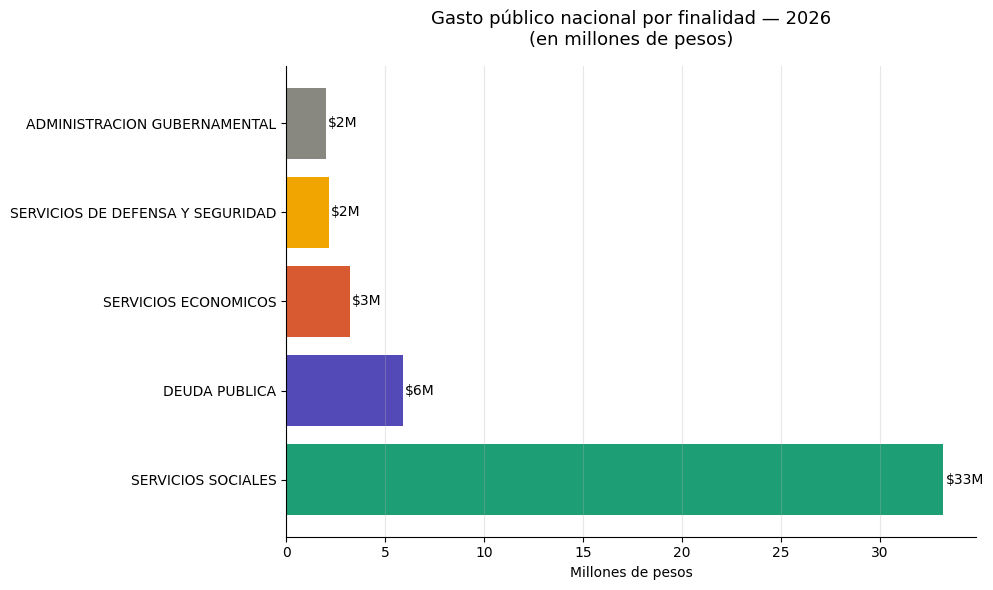

Gráfico guardado en dashboard/


In [9]:
import matplotlib.pyplot as plt

# Convertir a millones para que sea más legible
gasto_millones = gasto_finalidad / 1_000_000

fig, ax = plt.subplots(figsize=(10, 6))

colores = ['#1D9E75', '#534AB7', '#D85A30', '#F0A500', '#888780']

bars = ax.barh(gasto_millones.index, gasto_millones.values, color=colores)

# Etiquetas con valores
for bar, valor in zip(bars, gasto_millones.values):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'${valor:,.0f}M', va='center', fontsize=10)

ax.set_title('Gasto público nacional por finalidad — 2026\n(en millones de pesos)', 
             fontsize=13, pad=15)
ax.set_xlabel('Millones de pesos')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../dashboard/grafico_finalidad.png', dpi=150, bbox_inches='tight')
plt.show()

print("Gráfico guardado en dashboard/")


## 1. Composición del gasto público nacional por finalidad

El gasto público nacional se organiza en cinco grandes finalidades. 
En 2026 los **Servicios Sociales** concentran el 70% del total ejecutado, 
siendo la categoría dominante del presupuesto nacional. Le siguen en importancia 
la **Deuda Pública** y los **Servicios Económicos**.

Dentro de los Servicios Sociales, la **Seguridad Social** representa el rubro más 
significativo, absorbiendo la mayor parte del gasto social del Estado nacional.

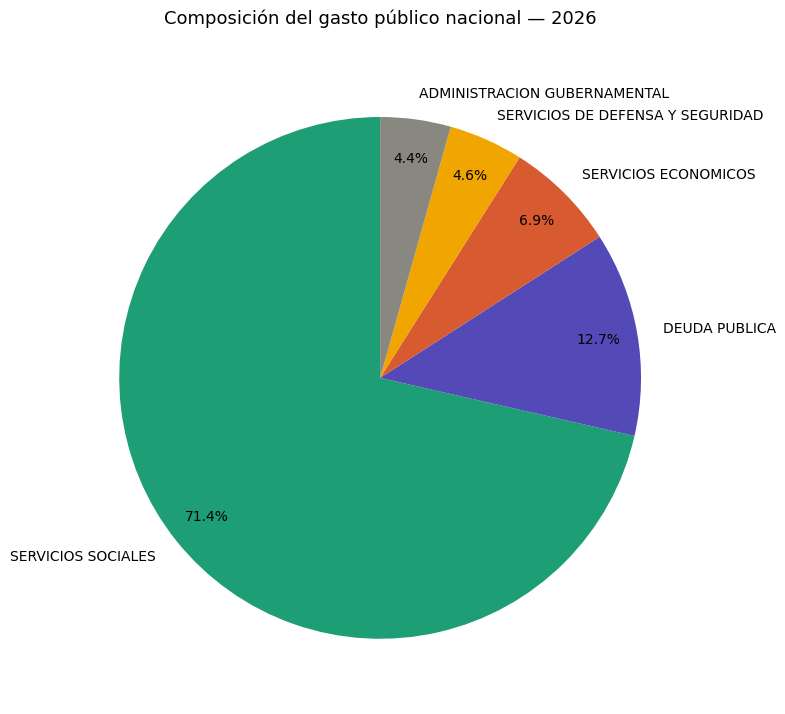

In [10]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.pie(gasto_millones.values, 
       labels=gasto_millones.index,
       colors=colores,
       autopct='%1.1f%%',
       startangle=90,
       pctdistance=0.85)

ax.set_title('Composición del gasto público nacional — 2026', 
             fontsize=13, pad=20)

plt.tight_layout()
plt.savefig('../dashboard/grafico_torta_finalidad.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Filtrar solo Servicios Sociales y agrupar por función
servicios_sociales = df_resumen[df_resumen['finalidad_desc'] == 'SERVICIOS SOCIALES']
gasto_funcion = servicios_sociales.groupby('funcion_desc')['credito_devengado'].sum().sort_values(ascending=False) / 1_000_000

print(gasto_funcion)

funcion_desc
Seguridad Social                    26.958723
Educación y Cultura                  2.275173
Salud                                2.139078
Promoción y Asistencia Social        0.904698
Ciencia, Tecnología e Innovación     0.503747
Trabajo                              0.359340
Agua Potable y Alcantarillado        0.056448
Vivienda y Urbanismo                 0.003628
Name: credito_devengado, dtype: float64


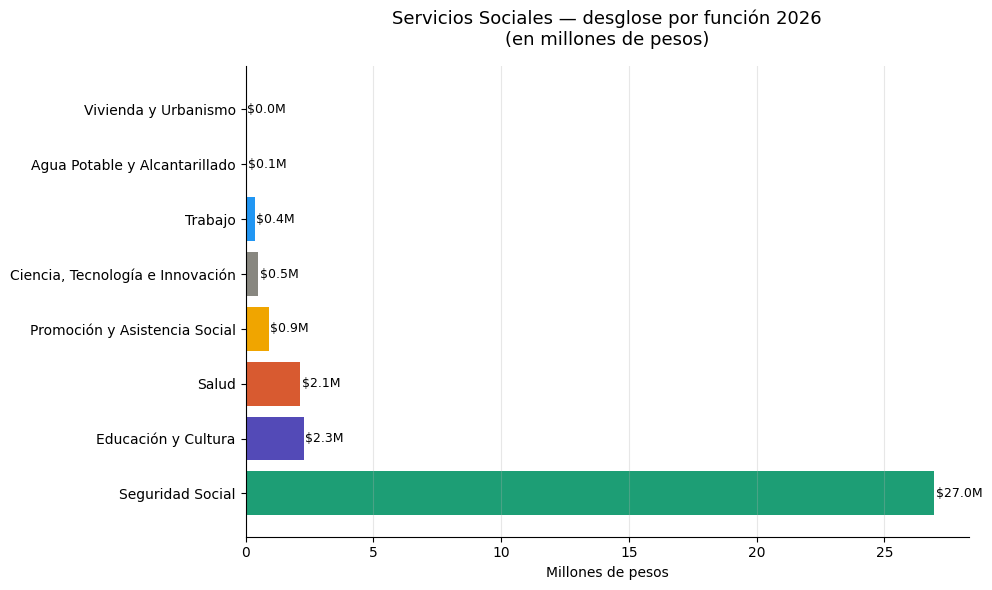

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

colores_ss = ['#1D9E75', '#534AB7', '#D85A30', '#F0A500', '#888780', '#2196F3', '#E91E63', '#795548']

bars = ax.barh(gasto_funcion.index, gasto_funcion.values, color=colores_ss)

for bar, valor in zip(bars, gasto_funcion.values):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'${valor:,.1f}M', va='center', fontsize=9)

ax.set_title('Servicios Sociales — desglose por función 2026\n(en millones de pesos)',
             fontsize=13, pad=15)
ax.set_xlabel('Millones de pesos')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../dashboard/grafico_servicios_sociales.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Cargar 2025
df_2025 = pd.read_csv('../datos/raw/resumen-presupuesto-gastos-ejercicio-vigente-2025.csv')

# Limpiar montos
df_2025['credito_devengado'] = df_2025['credito_devengado'].astype(str).str.replace(',', '.').astype(float)

# Agrupar por finalidad
gasto_2025 = df_2025.groupby('finalidad_desc')['credito_devengado'].sum() / 1_000_000

print("=== 2025 ===")
print(gasto_2025)
print("\n=== 2026 ===")
print(gasto_millones)

=== 2025 ===
finalidad_desc
ADMINISTRACION GUBERNAMENTAL         6.652753
DEUDA PUBLICA                       10.352974
SERVICIOS DE DEFENSA Y SEGURIDAD     6.075017
SERVICIOS ECONOMICOS                 9.539839
SERVICIOS SOCIALES                  90.257189
Name: credito_devengado, dtype: float64

=== 2026 ===
finalidad_desc
SERVICIOS SOCIALES                  33.200836
DEUDA PUBLICA                        5.888028
SERVICIOS ECONOMICOS                 3.220719
SERVICIOS DE DEFENSA Y SEGURIDAD     2.144020
ADMINISTRACION GUBERNAMENTAL         2.028107
Name: credito_devengado, dtype: float64


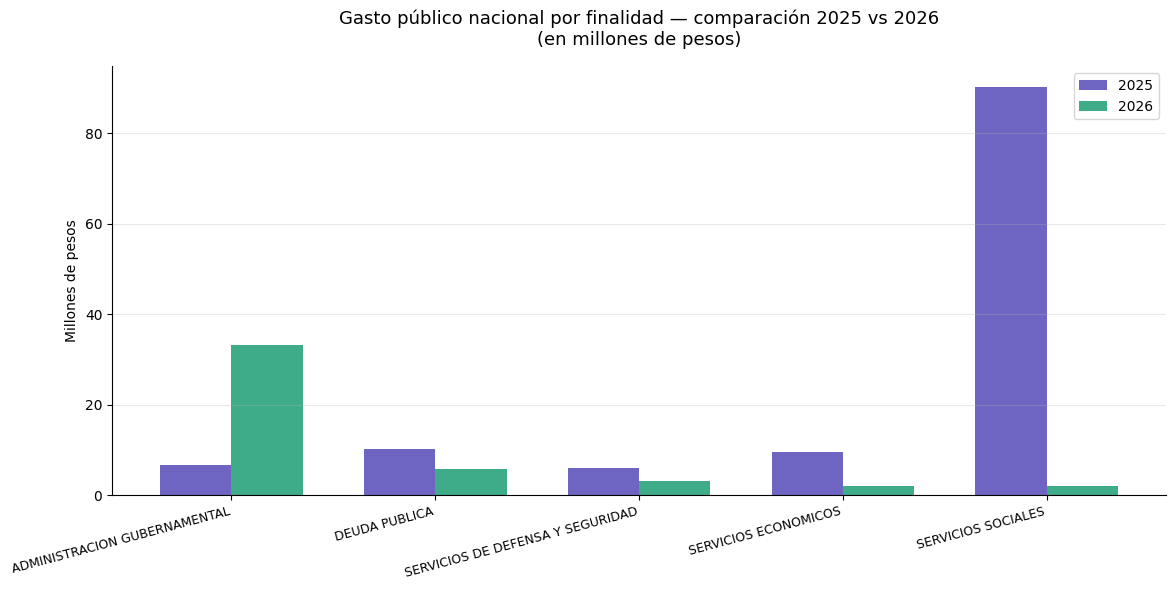

In [14]:
import numpy as np

fig, ax = plt.subplots(figsize=(12, 6))

categorias = gasto_2025.index
x = np.arange(len(categorias))
ancho = 0.35

barras_2025 = ax.bar(x - ancho/2, gasto_2025.values, ancho, 
                      label='2025', color='#534AB7', alpha=0.85)
barras_2026 = ax.bar(x + ancho/2, gasto_millones.values, ancho, 
                      label='2026', color='#1D9E75', alpha=0.85)

ax.set_title('Gasto público nacional por finalidad — comparación 2025 vs 2026\n(en millones de pesos)', 
             fontsize=13, pad=15)
ax.set_ylabel('Millones de pesos')
ax.set_xticks(x)
ax.set_xticklabels(categorias, rotation=15, ha='right', fontsize=9)
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../dashboard/grafico_comparacion_2025_2026.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
df_2024 = pd.read_csv('../datos/raw/credito-anual-2024.csv')
print(df_2024.head(3))
print("\nColumnas:", df_2024.columns.tolist())


   impacto_presupuestario_anio  ejercicio_presupuestario  sector_id  \
0                         2024                      2024          1   
1                         2024                      2024          1   
2                         2024                      2024          1   

                             sector_desc  subsector_id  \
0  Sector Público Nacional no Financiero             1   
1  Sector Público Nacional no Financiero             1   
2  Sector Público Nacional no Financiero             1   

            subsector_desc  caracter_id           caracter_desc  \
0  Administración Nacional            1  Administración Central   
1  Administración Nacional            1  Administración Central   
2  Administración Nacional            1  Administración Central   

   jurisdiccion_id           jurisdiccion_desc  ...  prestamo_externo_id  \
0                1  Poder Legislativo Nacional  ...                    0   
1                1  Poder Legislativo Nacional  ...          

In [16]:
# Limpiar montos
df_2024['credito_devengado'] = df_2024['credito_devengado'].astype(str).str.replace(',', '.').astype(float)

# Ver ubicaciones geográficas
print(df_2024['ubicacion_geografica_desc'].unique())

<StringArray>
[                                   'Ciudad Autónoma de Buenos Aires',
                                                     'No Clasificado',
                                          'Provincia de Buenos Aires',
                                                 'Provincia de Salta',
                                              'Provincia de Santa Fe',
                                               'Provincia de Córdoba',
                                               'Provincia de Tucumán',
                                             'Provincia de Catamarca',
                                                'Provincia del Chaco',
                                            'Provincia de Entre Ríos',
                                              'Provincia de La Pampa',
                                              'Provincia de Misiones',
                                             'Provincia de Río Negro',
                                              'Provincia de San

In [17]:
# Filtrar solo La Rioja
df_larioja_2024 = df_2024[df_2024['ubicacion_geografica_desc'] == 'Provincia de La Rioja']

print("Filas La Rioja:", len(df_larioja_2024))

# Gasto por finalidad en La Rioja
gasto_lr_2024 = df_larioja_2024.groupby('finalidad_desc')['credito_devengado'].sum() / 1_000_000

print("\nGasto nacional ejecutado en La Rioja por finalidad 2024:")
print(gasto_lr_2024)

Filas La Rioja: 1665

Gasto nacional ejecutado en La Rioja por finalidad 2024:
finalidad_desc
ADMINISTRACION GUBERNAMENTAL        0.001578
SERVICIOS DE DEFENSA Y SEGURIDAD    0.027389
SERVICIOS ECONOMICOS                0.005918
SERVICIOS SOCIALES                  0.477362
Name: credito_devengado, dtype: float64


In [18]:
# Ver el monto máximo para entender la escala
print("Monto máximo:", df_2024['credito_devengado'].max())
print("Monto mínimo no cero:", df_2024[df_2024['credito_devengado'] > 0]['credito_devengado'].min())

# Ver un ejemplo de La Rioja
print("\nEjemplo filas La Rioja:")
print(df_larioja_2024[['finalidad_desc', 'funcion_desc', 'credito_devengado']].head(10))

Monto máximo: 3833982.65809454
Monto mínimo no cero: 1e-08

Ejemplo filas La Rioja:
                    finalidad_desc funcion_desc  credito_devengado
877   ADMINISTRACION GUBERNAMENTAL  Legislativa           3.944941
2094  ADMINISTRACION GUBERNAMENTAL     Judicial           0.000000
2119  ADMINISTRACION GUBERNAMENTAL     Judicial           0.000000
2144  ADMINISTRACION GUBERNAMENTAL     Judicial           0.000000
2169  ADMINISTRACION GUBERNAMENTAL     Judicial           0.000000
2194  ADMINISTRACION GUBERNAMENTAL     Judicial           0.000000
2222  ADMINISTRACION GUBERNAMENTAL     Judicial           0.000000
2247  ADMINISTRACION GUBERNAMENTAL     Judicial           0.000000
2272  ADMINISTRACION GUBERNAMENTAL     Judicial           0.257300
2330  ADMINISTRACION GUBERNAMENTAL     Judicial           0.042477


In [19]:
# Gasto por finalidad en La Rioja SIN dividir por millón
gasto_lr_2024 = df_larioja_2024.groupby('finalidad_desc')['credito_devengado'].sum()

print("Gasto nacional ejecutado en La Rioja por finalidad 2024 (en millones de pesos):")
print(gasto_lr_2024)
print(f"\nTotal ejecutado en La Rioja: ${gasto_lr_2024.sum():,.1f} millones")


Gasto nacional ejecutado en La Rioja por finalidad 2024 (en millones de pesos):
finalidad_desc
ADMINISTRACION GUBERNAMENTAL          1577.652256
SERVICIOS DE DEFENSA Y SEGURIDAD     27388.585302
SERVICIOS ECONOMICOS                  5918.494010
SERVICIOS SOCIALES                  477361.979966
Name: credito_devengado, dtype: float64

Total ejecutado en La Rioja: $512,246.7 millones


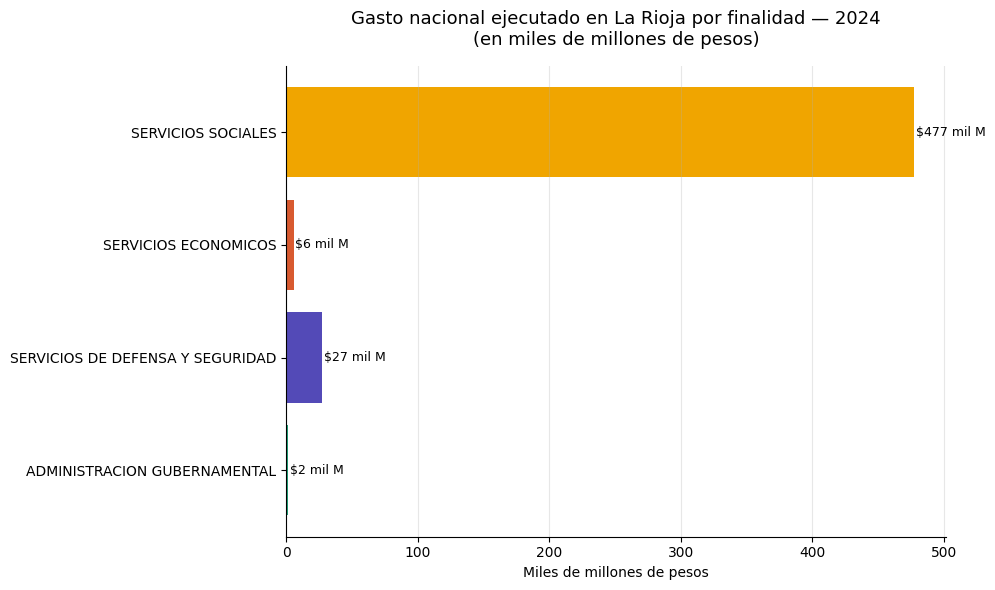

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))

colores_lr = ['#1D9E75', '#534AB7', '#D85A30', '#F0A500']

bars = ax.barh(gasto_lr_2024.index, gasto_lr_2024.values / 1000, color=colores_lr)

for bar, valor in zip(bars, gasto_lr_2024.values / 1000):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'${valor:,.0f} mil M', va='center', fontsize=9)

ax.set_title('Gasto nacional ejecutado en La Rioja por finalidad — 2024\n(en miles de millones de pesos)',
             fontsize=13, pad=15)
ax.set_xlabel('Miles de millones de pesos')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../dashboard/grafico_larioja_2024.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Gasto nacional ejecutado en La Rioja — 2024

Durante el ejercicio 2024 el gobierno nacional ejecutó **$512,247 millones** 
en la provincia de La Rioja. 

La distribución por finalidad muestra una fuerte concentración en 
**Servicios Sociales** (93% del total), principalmente explicada por el gasto 
en seguridad social, educación y salud. 

Los **Servicios de Defensa y Seguridad** ocupan el segundo lugar con el 5.3%, 
mientras que la **Administración Gubernamental** y los **Servicios Económicos** 
representan una porción marginal del gasto ejecutado en territorio provincial.

In [21]:
# Provincias del NOA
noa = [
    'Provincia de La Rioja',
    'Provincia de Catamarca', 
    'Provincia de Tucumán',
    'Provincia de Salta',
    'Provincia de Jujuy',
    'Provincia de Santiago del Estero'
]

df_noa = df_2024[df_2024['ubicacion_geografica_desc'].isin(noa)]

# Agrupar por provincia
gasto_noa = df_noa.groupby('ubicacion_geografica_desc')['credito_devengado'].sum().sort_values(ascending=False)

print("Gasto nacional ejecutado en provincias del NOA — 2024 (millones de pesos):")
print(gasto_noa)
print(f"\nTotal NOA: ${gasto_noa.sum():,.0f} millones")
print(f"La Rioja representa el {gasto_noa['Provincia de La Rioja']/gasto_noa.sum()*100:.1f}% del total NOA")

Gasto nacional ejecutado en provincias del NOA — 2024 (millones de pesos):
ubicacion_geografica_desc
Provincia de Tucumán                2.177671e+06
Provincia de Salta                  1.642369e+06
Provincia de Santiago del Estero    1.251771e+06
Provincia de Jujuy                  9.523877e+05
Provincia de Catamarca              6.011640e+05
Provincia de La Rioja               5.122467e+05
Name: credito_devengado, dtype: float64

Total NOA: $7,137,609 millones
La Rioja representa el 7.2% del total NOA


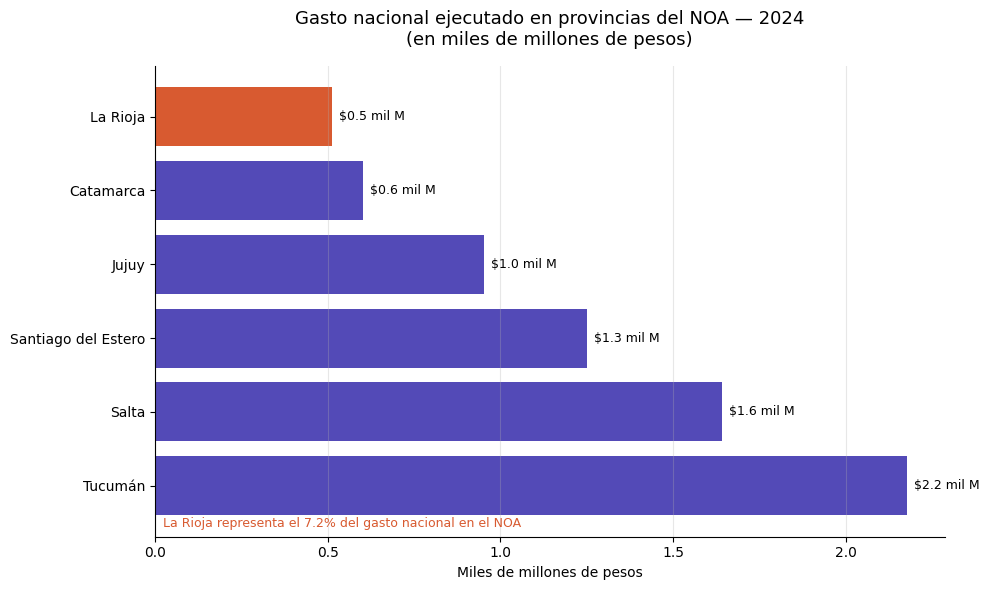

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))

# Nombres más cortos para el gráfico
etiquetas = [p.replace('Provincia de ', '').replace('Provincia del ', '') 
             for p in gasto_noa.index]

colores_noa = ['#534AB7', '#534AB7', '#534AB7', '#534AB7', '#534AB7', '#D85A30']
# La Rioja en color distinto (es la última después del sort)
colores_noa = ['#534AB7' if 'La Rioja' not in p else '#D85A30' 
               for p in gasto_noa.index]

bars = ax.barh(etiquetas, gasto_noa.values / 1_000_000, color=colores_noa)

for bar, valor in zip(bars, gasto_noa.values / 1_000_000):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f'${valor:,.1f} mil M', va='center', fontsize=9)

ax.set_title('Gasto nacional ejecutado en provincias del NOA — 2024\n(en miles de millones de pesos)',
             fontsize=13, pad=15)
ax.set_xlabel('Miles de millones de pesos')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.3)

# Nota al pie
ax.annotate('La Rioja representa el 7.2% del gasto nacional en el NOA',
            xy=(0.01, 0.02), xycoords='axes fraction', fontsize=9,
            color='#D85A30')

plt.tight_layout()
plt.savefig('../dashboard/grafico_noa_comparacion.png', dpi=150, bbox_inches='tight')
plt.show()

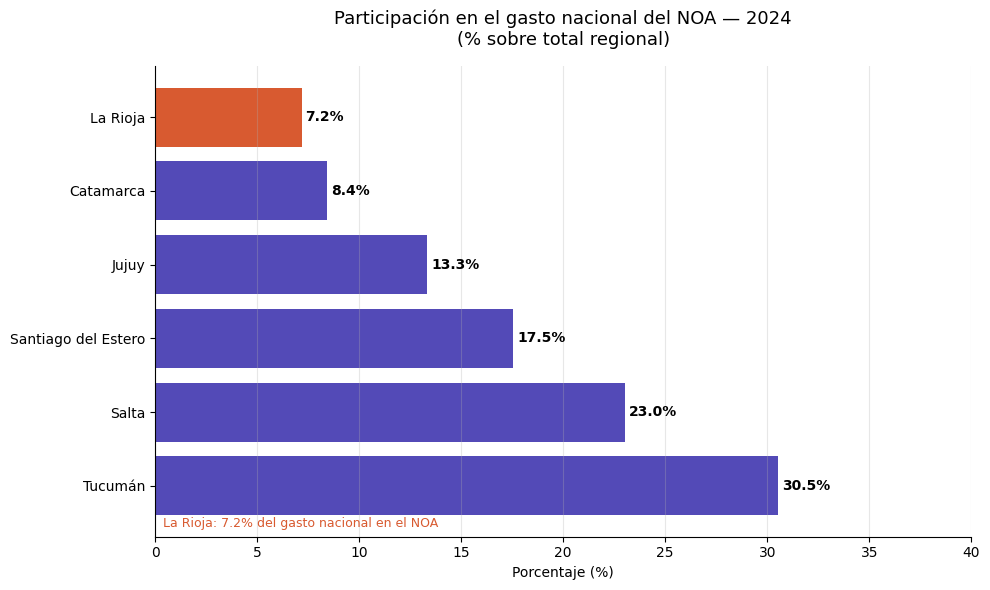

In [23]:
# Calcular porcentaje de cada provincia sobre el total NOA
gasto_noa_pct = (gasto_noa / gasto_noa.sum() * 100).sort_values(ascending=False)

etiquetas = [p.replace('Provincia de ', '') for p in gasto_noa_pct.index]

fig, ax = plt.subplots(figsize=(10, 6))

colores_noa = ['#D85A30' if 'La Rioja' in p else '#534AB7' for p in gasto_noa_pct.index]

bars = ax.barh(etiquetas, gasto_noa_pct.values, color=colores_noa)

for bar, valor in zip(bars, gasto_noa_pct.values):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{valor:.1f}%', va='center', fontsize=10, fontweight='bold')

ax.set_title('Participación en el gasto nacional del NOA — 2024\n(% sobre total regional)',
             fontsize=13, pad=15)
ax.set_xlabel('Porcentaje (%)')
ax.set_xlim(0, 40)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.3)

ax.annotate('La Rioja: 7.2% del gasto nacional en el NOA',
            xy=(0.01, 0.02), xycoords='axes fraction',
            fontsize=9, color='#D85A30')

plt.tight_layout()
plt.savefig('../dashboard/grafico_noa_porcentaje.png', dpi=150, bbox_inches='tight')
plt.show()